# Initialization

In [13]:
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import importlib
import matplotlib.pyplot as plt
import numpy as np

import dynamics.Dynamics_single_pendulum as Dynamics_single_pendulum
import utils.control_chain as control_chain_module
import utils.mpc as mpc_module

importlib.reload(Dynamics_single_pendulum)
importlib.reload(mpc_module)
importlib.reload(control_chain_module)

from utils.control_chain import (
    build_control_alphabet_from_saved_rollouts,
    evaluate_incremental_chain_policy,
    make_single_pendulum_mpc_backup,
    make_single_pendulum_spec,
)
from utils.mpc import SinglePendulumParams, build_single_pendulum_mpc, rollout_mpc


# Expert Data Synthesis

In [14]:
cfg = SinglePendulumParams(
    dt=0.02,
    n_horizon=120,
    x_ref=np.array([np.pi, 0.0], dtype=float),
)
_, mpc, simulator = build_single_pendulum_mpc(cfg)
sim_time = 10.0

single_initial_states = {
    "x0_0_0": np.array([0.0, 0.0], dtype=float),
    "x1_pi4_0": np.array([np.pi / 4.0, 0.0], dtype=float),
    "x2_pi2_0": np.array([np.pi / 2.0, 0.0], dtype=float),
    "x3_3pi4_0": np.array([3.0 * np.pi / 4.0, 0.0], dtype=float),
    "x4_pi_0": np.array([np.pi, 0.0], dtype=float),
    "x5_5pi4_0": np.array([5.0 * np.pi / 4.0, 0.0], dtype=float),
    "x6_3pi2_0": np.array([3.0 * np.pi / 2.0, 0.0], dtype=float),
    "x7_7pi4_0": np.array([7.0 * np.pi / 4.0, 0.0], dtype=float),
}

all_rollouts = {}
for name, x0 in single_initial_states.items():
    T, X, U = rollout_mpc(mpc, simulator, x0, sim_time=sim_time, save_U=False)
    all_rollouts[name] = (T, X, U)

save_dir = os.path.expanduser("~/exp/Nonparameric_Hamiltonian_Systems/data")
os.makedirs(save_dir, exist_ok=True)

for name, (T, X, U) in all_rollouts.items():
    np.save(os.path.join(save_dir, f"T_{name}.npy"), T)
    np.save(os.path.join(save_dir, f"X_{name}.npy"), X)
    np.save(os.path.join(save_dir, f"U_{name}.npy"), U)

np.savez(
    os.path.join(save_dir, "all_rollouts_single_pendulum.npz"),
    target_state=cfg.x_ref,
    **{f"T_{k}": v[0] for k, v in all_rollouts.items()},
    **{f"X_{k}": v[1] for k, v in all_rollouts.items()},
    **{f"U_{k}": v[2] for k, v in all_rollouts.items()},
)

print("Saved single-pendulum expert rollouts to:", save_dir)

Saved single-pendulum expert rollouts to: /home/jixia/exp/Nonparameric_Hamiltonian_Systems/data


/tmp/ipykernel_1486/3379118416.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.99])


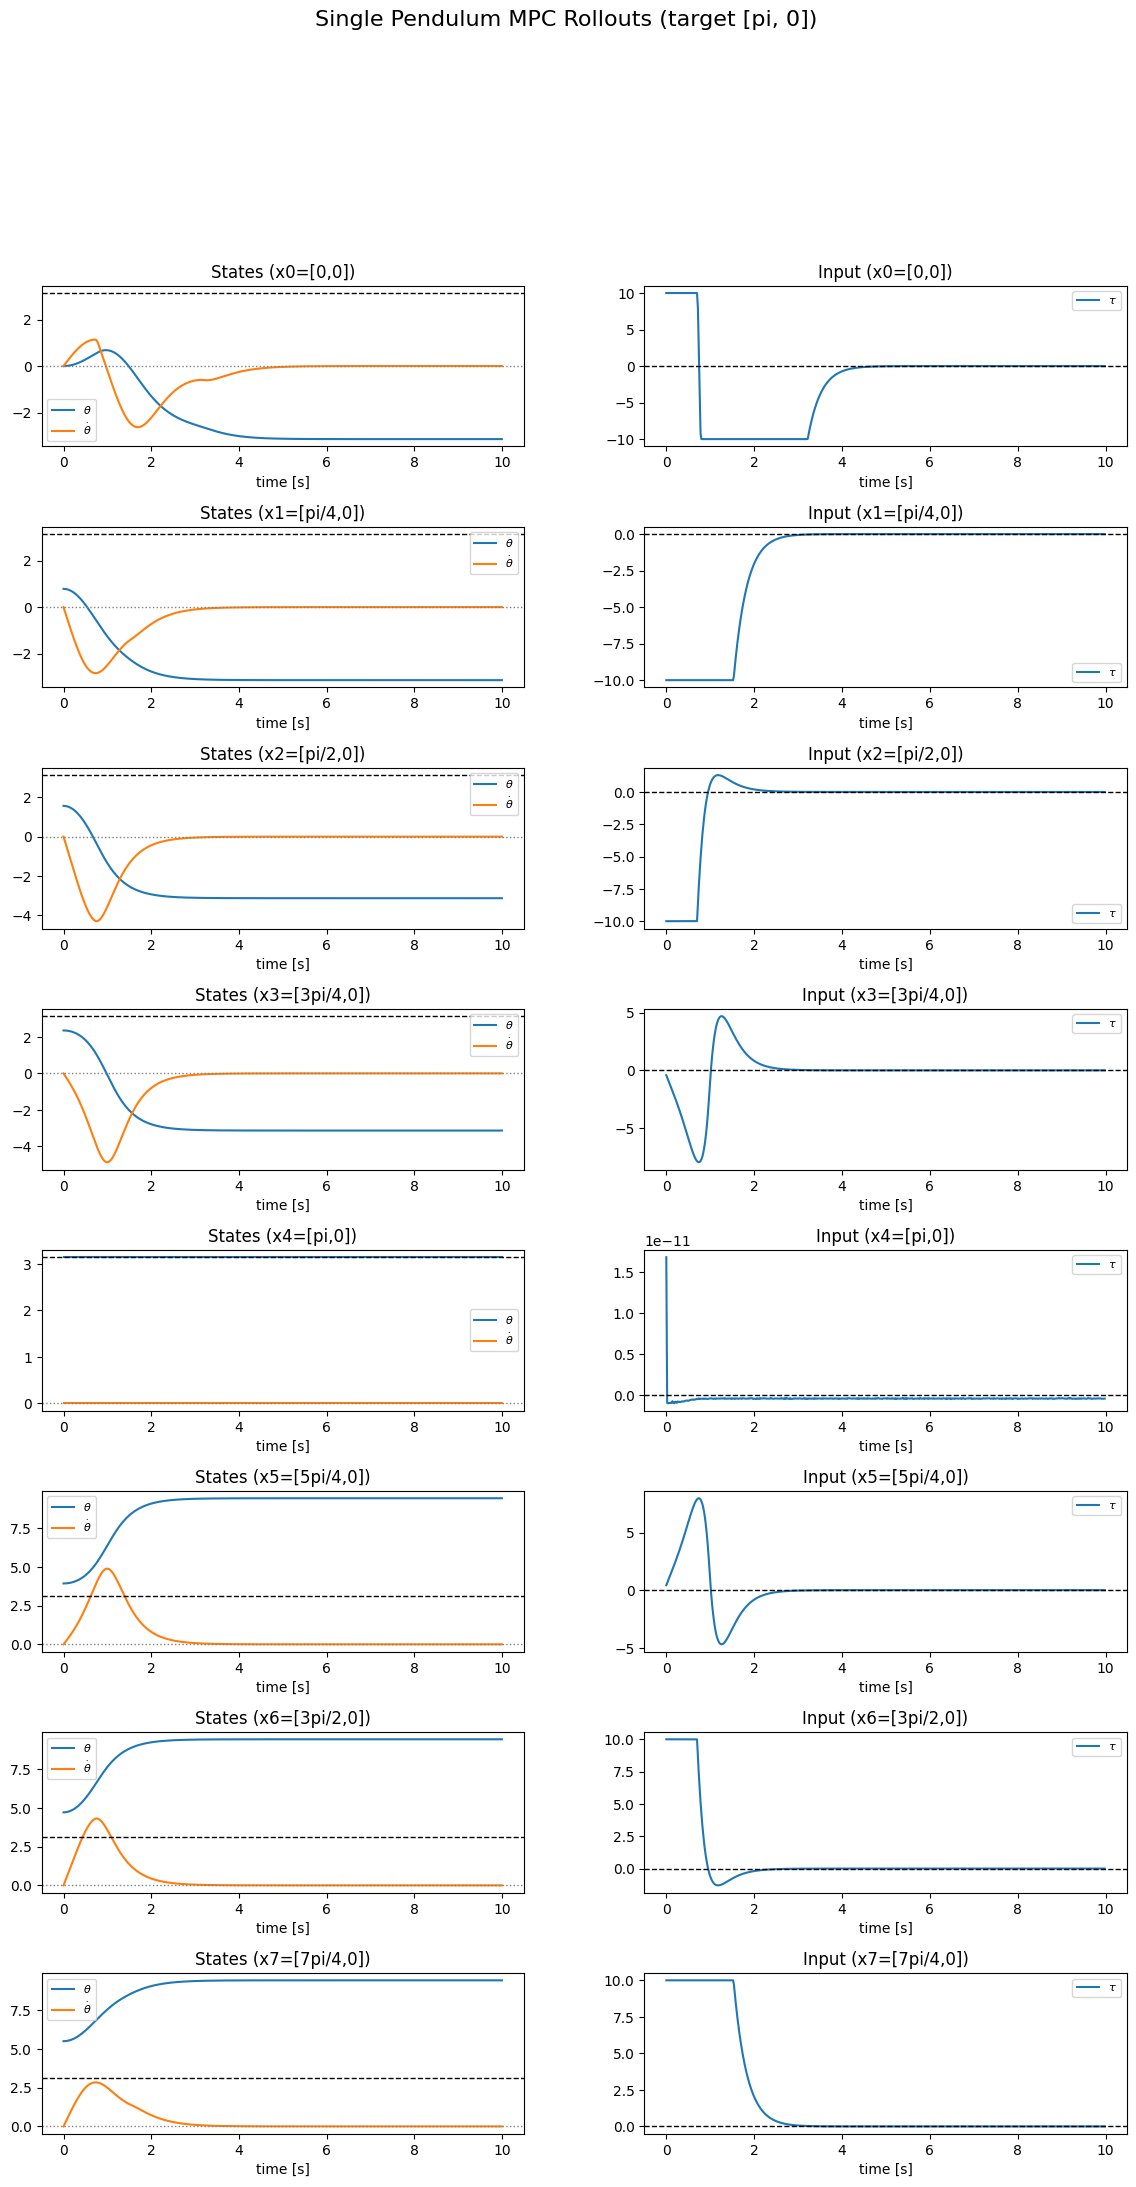

In [15]:
save_dir = os.path.expanduser("~/exp/Nonparameric_Hamiltonian_Systems/data")
npz_path = os.path.join(save_dir, "all_rollouts_single_pendulum.npz")
data = np.load(npz_path, allow_pickle=True)

cases = [
    ("x0=[0,0]", "x0_0_0"),
    ("x1=[pi/4,0]", "x1_pi4_0"),
    ("x2=[pi/2,0]", "x2_pi2_0"),
    ("x3=[3pi/4,0]", "x3_3pi4_0"),
    ("x4=[pi,0]", "x4_pi_0"),
    ("x5=[5pi/4,0]", "x5_5pi4_0"),
    ("x6=[3pi/2,0]", "x6_3pi2_0"),
    ("x7=[7pi/4,0]", "x7_7pi4_0"),
]

fig = plt.figure(figsize=(14, 3 * len(cases)))
gs = fig.add_gridspec(len(cases), 2, hspace=0.5, wspace=0.25)

for row, (label, key) in enumerate(cases):
    T = data[f"T_{key}"]
    X = data[f"X_{key}"]
    U = data[f"U_{key}"]

    ax_state = fig.add_subplot(gs[row, 0])
    ax_state.plot(T, X[:, 0], label=r"$\theta$")
    ax_state.plot(T, X[:, 1], label=r"$\dot{\theta}$")
    ax_state.axhline(np.pi, ls="--", lw=1, color="k")
    ax_state.axhline(0.0, ls=":", lw=1, color="gray")
    ax_state.set_title(f"States ({label})")
    ax_state.set_xlabel("time [s]")
    ax_state.legend(loc="best", fontsize=8)

    ax_u = fig.add_subplot(gs[row, 1])
    t_u = T[:-1] if U.shape[0] == T.shape[0] - 1 else T[: U.shape[0]]
    ax_u.plot(t_u, U[:, 0], label=r"$\tau$")
    ax_u.axhline(0.0, ls="--", lw=1, color="k")
    ax_u.set_title(f"Input ({label})")
    ax_u.set_xlabel("time [s]")
    ax_u.legend(loc="best", fontsize=8)

fig.suptitle("Single Pendulum MPC Rollouts (target [pi, 0])", y=0.995, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()


# Chain Policy

In [16]:
save_dir = os.path.expanduser("~/exp/Nonparameric_Hamiltonian_Systems/data")
spec = make_single_pendulum_spec()
single_names = list(single_initial_states.keys())
dense_names = [f"th{k:02d}" for k in range(16)]

generation_cfg = {
    "rho": 0.99,
    "H_star": 0.0,
    "eta": 0.0,
    "r_min": 1e-6,
    "max_lookahead": 200,
    "eps_L": 1e-5,
}

baseline_cfg = {
    "execute_full_sequence": True,
    "outside_mode": "nearest_sequence",
    "radius_scale": 12.0,
    "enter_threshold": 1.0,
    "abort_threshold": 50.0,
    "distance_weights": (1.0, 0.1),
}

stitch_cfg = {
    **baseline_cfg,
    "selection_mode": "stitch",
    "stitch_top_k": 8,
    "stitch_threshold": 3.0,
    "stitch_entry_weight": 1.0,
    "stitch_value_weight": 0.35,
}

# Dense demonstrations improved the pure chain more than extra stitching.
dense_cfg = dict(baseline_cfg)
tracking_cfg = {
    **dense_cfg,
    "tracking_gain": np.array([[10.0, 4.0]], dtype=np.float32),
    "u_min": np.array([-10.0], dtype=np.float32),
    "u_max": np.array([10.0], dtype=np.float32),
}

# Online MPC backup is much slower. Quick mode keeps the notebook runnable.
use_quick_single_backup = True
single_backup_names = dense_names[:4] if use_quick_single_backup else dense_names
single_backup_num_inits = 4 if use_quick_single_backup else 12

_, sparse_alphabet_summary = build_control_alphabet_from_saved_rollouts(
    spec=spec,
    save_dir=save_dir,
    names=single_names,
    verbose=False,
    save_metrics=True,
    **generation_cfg,
)

_, dense_alphabet_summary = build_control_alphabet_from_saved_rollouts(
    spec=spec,
    save_dir=save_dir,
    names=dense_names,
    npz_filename="all_rollouts_single_pendulum_dense.npz",
    alphabet_filename="control_alphabet_single_pendulum_dense.pkl",
    verbose=False,
    save_metrics=True,
    **generation_cfg,
)

{
    "sparse": sparse_alphabet_summary,
    "dense": dense_alphabet_summary,
}


{'sparse': [{'name': 'x0_0_0',
   'n_tubes': 27,
   'r_min': 1.507081459046418e-06,
   'r_mean': 0.02387275353694325,
   'r_median': 0.007067779081554328,
   'r_max': 0.10398940603472132},
  {'name': 'x1_pi4_0',
   'n_tubes': 20,
   'r_min': 4.0226104196112995e-06,
   'r_mean': 0.025515730598804392,
   'r_median': 0.002600453821471063,
   'r_max': 0.11146335997086529},
  {'name': 'x2_pi2_0',
   'n_tubes': 19,
   'r_min': 1.0574745660014087e-06,
   'r_mean': 0.01235106116164092,
   'r_median': 3.7118798222967e-05,
   'r_max': 0.10169543870120164},
  {'name': 'x3_3pi4_0',
   'n_tubes': 18,
   'r_min': 1.0318530847659178e-06,
   'r_mean': 0.0014121673592852597,
   'r_median': 3.7864767126202414e-05,
   'r_max': 0.02036551678074297},
  {'name': 'x4_pi_0',
   'n_tubes': 0,
   'r_min': nan,
   'r_mean': nan,
   'r_median': nan,
   'r_max': nan},
  {'name': 'x5_5pi4_0',
   'n_tubes': 18,
   'r_min': 1.0318526287684509e-06,
   'r_mean': 0.0014121673298644099,
   'r_median': 3.786476675357146e-

[TubeController] loaded 27 tubes.
[TubeController] effective radius stats: min/med/max = 1.808e-05/8.481e-02/1.248e+00
[TubeController] loaded 47 tubes.
[TubeController] effective radius stats: min/med/max = 1.808e-05/4.720e-02/1.338e+00
[TubeController] loaded 66 tubes.
[TubeController] effective radius stats: min/med/max = 1.269e-05/8.354e-03/1.338e+00
[TubeController] loaded 84 tubes.
[TubeController] effective radius stats: min/med/max = 1.238e-05/3.681e-03/1.338e+00
[TubeController] loaded 84 tubes.
[TubeController] effective radius stats: min/med/max = 1.238e-05/3.681e-03/1.338e+00
[TubeController] loaded 102 tubes.
[TubeController] effective radius stats: min/med/max = 1.238e-05/2.490e-03/1.338e+00
[TubeController] loaded 121 tubes.
[TubeController] effective radius stats: min/med/max = 1.238e-05/1.662e-03/1.338e+00
[TubeController] loaded 141 tubes.
[TubeController] effective radius stats: min/med/max = 1.238e-05/2.780e-03/1.338e+00
[TubeController] loaded 27 tubes.
[TubeContro

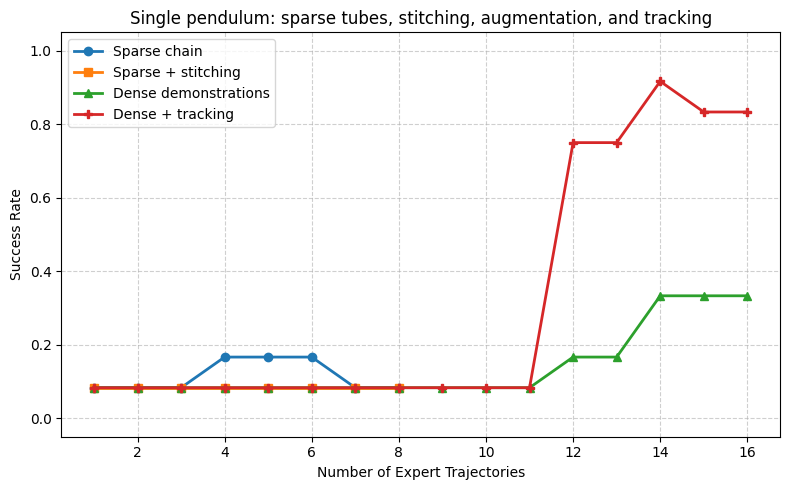

In [17]:
baseline_init_states = spec.sample_initial_states(num_inits=12, seed=123)

n_traj_baseline, success_rates_baseline, diag_baseline = evaluate_incremental_chain_policy(
    spec=spec,
    save_dir=save_dir,
    target_names=single_names,
    init_states=baseline_init_states,
    dt=0.02,
    episode_seconds=20.0,
    controller_kwargs=baseline_cfg,
    result_filename="incremental_tube_success_rates_single_pendulum.npz",
    plot=False,
    verbose=False,
)

n_traj_stitch, success_rates_stitch, diag_stitch = evaluate_incremental_chain_policy(
    spec=spec,
    save_dir=save_dir,
    target_names=single_names,
    init_states=baseline_init_states,
    dt=0.02,
    episode_seconds=20.0,
    controller_kwargs=stitch_cfg,
    result_filename="incremental_tube_success_rates_single_pendulum_stitch.npz",
    plot=False,
    verbose=False,
)

n_traj_dense, success_rates_dense, diag_dense = evaluate_incremental_chain_policy(
    spec=spec,
    save_dir=save_dir,
    target_names=dense_names,
    init_states=baseline_init_states,
    dt=0.02,
    episode_seconds=20.0,
    controller_kwargs=dense_cfg,
    alphabet_filename="control_alphabet_single_pendulum_dense.pkl",
    result_filename="incremental_tube_success_rates_single_pendulum_dense.npz",
    plot=False,
    verbose=False,
)

n_traj_track, success_rates_track, diag_track = evaluate_incremental_chain_policy(
    spec=spec,
    save_dir=save_dir,
    target_names=dense_names,
    init_states=baseline_init_states,
    dt=0.02,
    episode_seconds=20.0,
    controller_kwargs=tracking_cfg,
    alphabet_filename="control_alphabet_single_pendulum_dense.pkl",
    result_filename="incremental_tube_success_rates_single_pendulum_tracking.npz",
    plot=False,
    verbose=False,
)

print("sparse baseline n_traj_list =", n_traj_baseline)
print("sparse baseline success_rates =", success_rates_baseline)
print("sparse stitch success_rates =", success_rates_stitch)
print("dense augmentation n_traj_list =", n_traj_dense)
print("dense augmentation success_rates =", success_rates_dense)
print("dense + tracking success_rates =", success_rates_track)

plt.figure(figsize=(8, 5))
plt.plot(n_traj_baseline, success_rates_baseline, marker="o", linewidth=2, label="Sparse chain")
plt.plot(n_traj_stitch, success_rates_stitch, marker="s", linewidth=2, label="Sparse + stitching")
plt.plot(n_traj_dense, success_rates_dense, marker="^", linewidth=2, label="Dense demonstrations")
plt.plot(n_traj_track, success_rates_track, marker="P", linewidth=2, label="Dense + tracking")
plt.xlabel("Number of Expert Trajectories")
plt.ylabel("Success Rate")
plt.title("Single pendulum: sparse tubes, stitching, augmentation, and tracking")
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


[TubeController] loaded 27 tubes.
[TubeController] effective radius stats: min/med/max = 1.507e-06/7.068e-03/1.040e-01
[TubeController] loaded 33 tubes.
[TubeController] effective radius stats: min/med/max = 1.031e-06/3.985e-03/1.040e-01
[TubeController] loaded 39 tubes.
[TubeController] effective radius stats: min/med/max = 1.031e-06/1.390e-03/1.040e-01
[TubeController] loaded 61 tubes.
[TubeController] effective radius stats: min/med/max = 1.031e-06/9.201e-04/1.082e-01
backup-reference n_traj_list = [1, 2, 3, 4]
backup-reference success_rates = [0.75, 0.75, 0.75, 0.75]


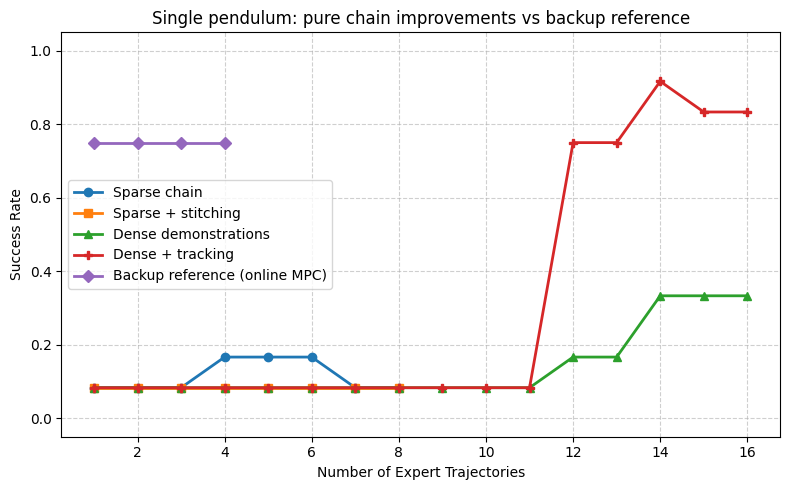

In [18]:
backup_reference_cfg = {
    "execute_full_sequence": False,
    "outside_mode": "backup",
    "backup_controller": make_single_pendulum_mpc_backup(dt=0.02, n_horizon=30),
    "enter_threshold": 0.0,
    "radius_scale": 1.0,
    "distance_weights": (1.0, 0.1),
}

backup_init_states = spec.sample_initial_states(num_inits=single_backup_num_inits, seed=7)

n_traj_backup, success_rates_backup, diag_backup = evaluate_incremental_chain_policy(
    spec=spec,
    save_dir=save_dir,
    target_names=single_backup_names,
    init_states=backup_init_states,
    dt=0.02,
    episode_seconds=8.0,
    controller_kwargs=backup_reference_cfg,
    alphabet_filename="control_alphabet_single_pendulum_dense.pkl",
    result_filename="incremental_tube_success_rates_single_pendulum_backup_reference.npz",
    plot=False,
    verbose=False,
)

print("backup-reference n_traj_list =", n_traj_backup)
print("backup-reference success_rates =", success_rates_backup)

plt.figure(figsize=(8, 5))
plt.plot(n_traj_baseline, success_rates_baseline, marker="o", linewidth=2, label="Sparse chain")
plt.plot(n_traj_stitch, success_rates_stitch, marker="s", linewidth=2, label="Sparse + stitching")
plt.plot(n_traj_dense, success_rates_dense, marker="^", linewidth=2, label="Dense demonstrations")
plt.plot(n_traj_track, success_rates_track, marker="P", linewidth=2, label="Dense + tracking")
plt.plot(n_traj_backup, success_rates_backup, marker="D", linewidth=2, label="Backup reference (online MPC)")
plt.xlabel("Number of Expert Trajectories")
plt.ylabel("Success Rate")
plt.title("Single pendulum: pure chain improvements vs backup reference")
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()